# Lesson 1.8 — 1D Burgers' Equation

## The Traffic Jam Meets the Heat Rod

What if the conveyor belt in Lesson 1.6 moved at the speed of the object sitting on it?
Faster objects catch up to slower ones in front and pile up — a shock forms, like cars
crashing into gridlock. Add some diffusion (viscosity) to smooth the shock and you
have **Burgers' equation**:

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}$$

This is the **simplest nonlinear PDE** that captures the essential physics of the
Navier-Stokes equations:

- $u \partial_x u$ — nonlinear advection (same form as the inertia term in N-S)
- $\nu \partial_{xx} u$ — viscous diffusion

The ratio $1/\nu$ plays the role of the Reynolds number. High $\nu$: smooth, diffusive.
Low $\nu$: sharp shocks that nearly blow up.

---

## Conservative vs. Non-Conservative Form

**Non-conservative** (advective form):
$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}$$

**Conservative** (flux form):
$$\frac{\partial u}{\partial t} + \frac{\partial}{\partial x}\left(\frac{u^2}{2}\right) = \nu \frac{\partial^2 u}{\partial x^2}$$

Both are mathematically equivalent for smooth solutions, but **the conservative form is
required to capture shocks correctly**. Non-conservative schemes give the wrong shock speed.
This is why the N-S equations are always written in conservation form in CFD codes.

---

## Shock Formation

For the inviscid Burgers' equation ($\nu=0$), characteristics are lines $x = x_0 + u_0(x_0) t$.
When two characteristics cross, the solution becomes multi-valued — a shock must form.

The shock formation time is: $t_s = -1/\min(u_0')$

Adding viscosity ($\nu > 0$) regularizes the shock into a smooth transition layer of
thickness $\sim \sqrt{\nu}$.


/var/folders/j6/slfvk4c54yj6lt99pq5rjh8m0000gn/T/ipykernel_6943/4206251362.py:11: RuntimeWarning: overflow encountered in square
  F = 0.5 * u_old**2
/var/folders/j6/slfvk4c54yj6lt99pq5rjh8m0000gn/T/ipykernel_6943/4206251362.py:14: RuntimeWarning: invalid value encountered in subtract
  u[1:-1] = u_old[1:-1] - dt/dx * (F_right[1:] - F_right[:-1])
/var/folders/j6/slfvk4c54yj6lt99pq5rjh8m0000gn/T/ipykernel_6943/4206251362.py:23: RuntimeWarning: invalid value encountered in add
  d2u[1:-1] = (u_old[2:] - 2*u_old[1:-1] + u_old[:-2]) / dx**2


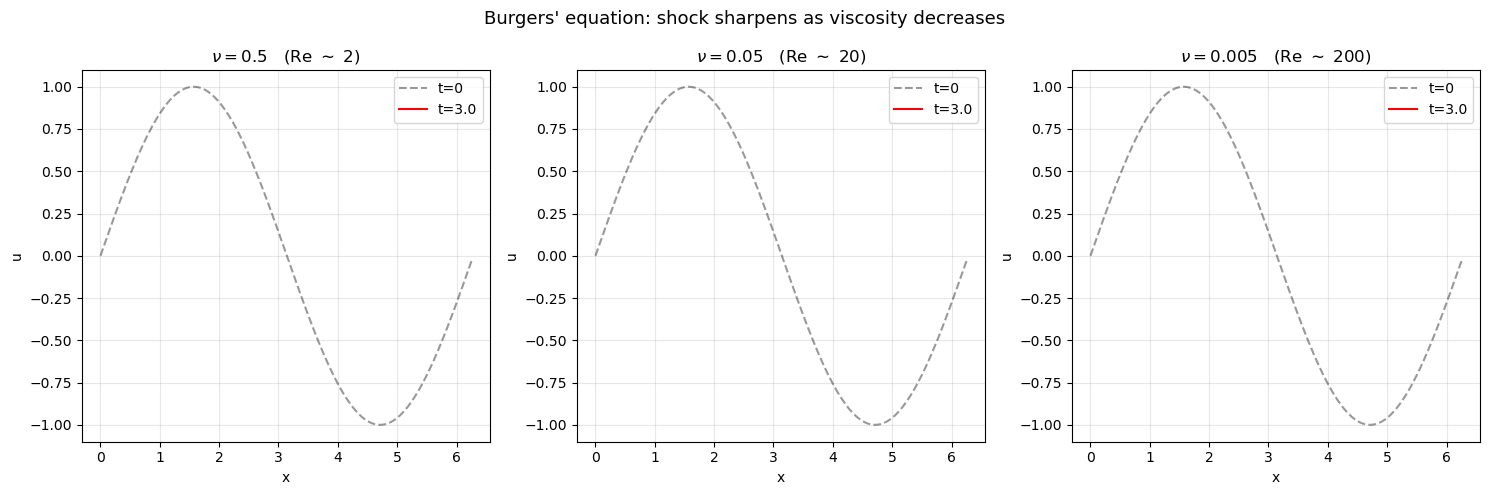

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def solve_burgers(u0, nu, dx, dt, nt, scheme='conservative'):
    """Solve 1D Burgers equation using upwind/central differences."""
    u = u0.copy()
    for _ in range(nt):
        u_old = u.copy()
        if scheme == 'conservative':
            # Conservative flux: F = u²/2
            F = 0.5 * u_old**2
            # Lax-Friedrichs flux at interfaces
            F_right = 0.5*(F[1:] + F[:-1]) - 0.5*(dx/dt)*(u_old[1:] - u_old[:-1])
            u[1:-1] = u_old[1:-1] - dt/dx * (F_right[1:] - F_right[:-1])
        else:
            # Non-conservative: u * du/dx
            dudx = np.zeros_like(u_old)
            dudx[1:-1] = (u_old[2:] - u_old[:-2]) / (2*dx)
            u[1:-1] = u_old[1:-1] - dt * u_old[1:-1] * dudx[1:-1]

        # Viscous term (central, explicit)
        d2u = np.zeros_like(u)
        d2u[1:-1] = (u_old[2:] - 2*u_old[1:-1] + u_old[:-2]) / dx**2
        u[1:-1] += dt * nu * d2u[1:-1]

        # BCs: periodic
        u[0] = u[-2]
        u[-1] = u[1]
    return u

# Setup: sine wave initial condition — will steepen into a shock
N  = 200
L  = 2*np.pi
dx = L / N
x  = np.linspace(0, L, N, endpoint=False)
u0 = np.sin(x)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

nu_values = [0.5, 0.05, 0.005]
for ax, nu in zip(axes, nu_values):
    dt = 0.4 * min(dx / np.max(np.abs(u0) + 1e-10), 0.5 * dx**2 / (nu + 1e-12))
    T  = 3.0
    nt = int(T / dt)
    u_final = solve_burgers(u0, nu, dx, dt, nt)
    
    ax.plot(x, u0, 'k--', alpha=0.4, label='t=0')
    ax.plot(x, u_final, 'r-', linewidth=1.5, label=f't={T}')
    ax.set_title(f'$\\nu = {nu}$   (Re $\\sim$ {1/nu:.0f})')
    ax.set_xlabel('x')
    ax.set_ylabel('u')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Burgers' equation: shock sharpens as viscosity decreases", fontsize=13)
plt.tight_layout()
plt.show()

Shock formation time: t_s = 1.0000 (exact: 1.0)


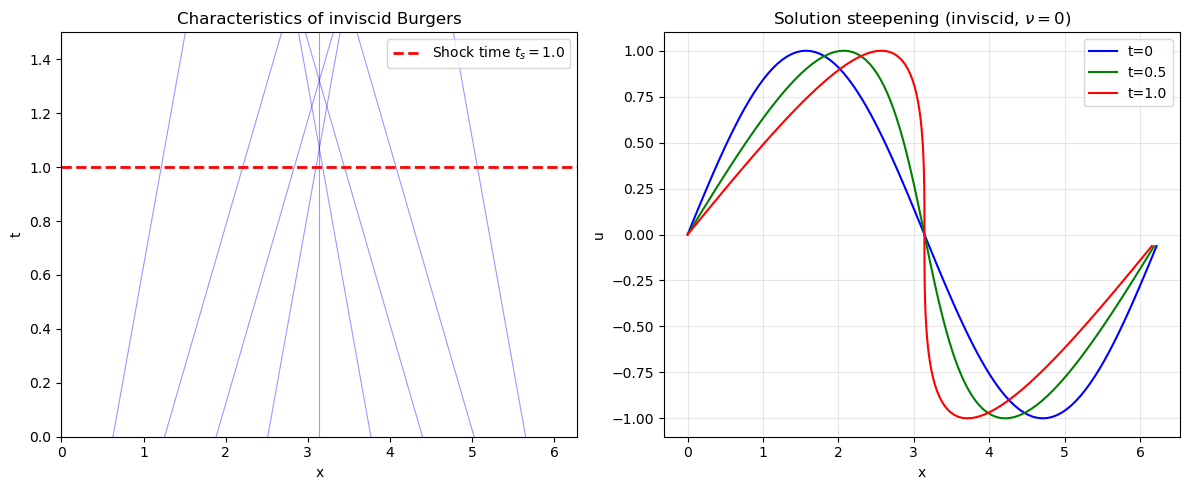

In [2]:
# Demonstrate shock formation time from characteristics
# u0 = sin(x) → t_shock = 1 (earliest time characteristics cross)

N  = 100
x  = np.linspace(0, 2*np.pi, N, endpoint=False)
u0 = np.sin(x)

# Shock formation time: t_s = -1/min(u0')
du0_dx = np.cos(x)  # exact derivative of sin(x)
t_shock = -1.0 / np.min(du0_dx)  # du0/dx has minimum = -1 at x=pi
print(f"Shock formation time: t_s = {t_shock:.4f} (exact: 1.0)")

# Characteristic lines: x(t) = x0 + u0(x0)*t
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Show characteristic lines
t_range = np.linspace(0, 1.5, 100)
x0_select = x[::10]  # every 10th point
u0_select  = u0[::10]

for x0i, u0i in zip(x0_select, u0_select):
    x_char = x0i + u0i * t_range
    axes[0].plot(x_char, t_range, 'b-', alpha=0.4, linewidth=0.8)

axes[0].axhline(t_shock, color='r', linestyle='--', linewidth=2, label=f'Shock time $t_s={t_shock:.1f}$')
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
axes[0].set_title('Characteristics of inviscid Burgers')
axes[0].legend()
axes[0].set_xlim(0, 2*np.pi)
axes[0].set_ylim(0, 1.5)

# Solution at different times
for t_plot, color in zip([0, 0.5, 1.0], ['blue', 'green', 'red']):
    # Method of characteristics (valid before shock)
    x_char = x + u0 * t_plot
    # Sort to get single-valued solution (approximation before crossing)
    idx = np.argsort(x_char)
    axes[1].plot(x_char[idx], u0[idx], color=color, label=f't={t_plot}')

axes[1].set_xlabel('x')
axes[1].set_ylabel('u')
axes[1].set_title('Solution steepening (inviscid, $\\nu=0$)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Key Takeaways

- Burgers' equation $\partial_t u + u \partial_x u = \nu \partial_{xx} u$ combines advection and diffusion.
- The nonlinear term $u \partial_x u$ causes wave steepening — fast parts catch slow parts.
- A shock forms at time $t_s = -1/\min(u_0')$ for inviscid flow.
- Always use the **conservative form** near shocks — non-conservative gives wrong shock speeds.
- High viscosity ($\nu$ large) smears shocks; low viscosity creates thin sharp layers.
- This equation is a 1D prototype for the N-S equations — master it before moving to 2D.

---

**End of Module 1.** You now have a working knowledge of conservation laws, finite differences,
and 1D solvers for advection, diffusion, and nonlinear wave propagation.

**Next**: Module 2, Lesson 1 — Extending to 2D: structured grids and scalar transport.
